In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
import plotly.express as px 

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("world-data-2023.csv")

#pd.set_option('display.max_columns', None)   
#pd.set_option('display.max_rows', None)      
#pd.set_option('display.max_colwidth', None)  

df

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.10%,"652,230","323,000",32.49,93.0,Kabul,"8,672",...,78.40%,0.28,"38,041,754",48.90%,9.30%,71.40%,11.12%,"9,797,273",33.939110,67.709953
1,Albania,105,AL,43.10%,"28,748","9,000",11.78,355.0,Tirana,"4,536",...,56.90%,1.20,"2,854,191",55.70%,18.60%,36.60%,12.33%,"1,747,593",41.153332,20.168331
2,Algeria,18,DZ,17.40%,"2,381,741","317,000",24.28,213.0,Algiers,"150,006",...,28.10%,1.72,"43,053,054",41.20%,37.20%,66.10%,11.70%,"31,510,100",28.033886,1.659626
3,Andorra,164,AD,40.00%,468,NaN,7.20,376.0,Andorra la Vella,469,...,36.40%,3.33,"77,142",NaN,NaN,NaN,NaN,"67,873",42.506285,1.521801
4,Angola,26,AO,47.50%,"1,246,700","117,000",40.73,244.0,Luanda,"34,693",...,33.40%,0.21,"31,825,295",77.50%,9.20%,49.10%,6.89%,"21,061,025",-11.202692,17.873887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32,VE,24.50%,"912,050","343,000",17.88,58.0,Caracas,"164,175",...,45.80%,1.92,"28,515,829",59.70%,NaN,73.30%,8.80%,"25,162,368",6.423750,-66.589730
191,Vietnam,314,VN,39.30%,"331,210","522,000",16.75,84.0,Hanoi,"192,668",...,43.50%,0.82,"96,462,106",77.40%,19.10%,37.60%,2.01%,"35,332,140",14.058324,108.277199
192,Yemen,56,YE,44.60%,"527,968","40,000",30.45,967.0,Sanaa,"10,609",...,81.00%,0.31,"29,161,922",38.00%,NaN,26.60%,12.91%,"10,869,523",15.552727,48.516388
193,Zambia,25,ZM,32.10%,"752,618","16,000",36.19,260.0,Lusaka,"5,141",...,27.50%,1.19,"17,861,030",74.60%,16.20%,15.60%,11.43%,"7,871,713",-13.133897,27.849332


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 35 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Country                                    195 non-null    object 
 1   Density
(P/Km2)                            195 non-null    object 
 2   Abbreviation                               188 non-null    object 
 3   Agricultural Land( %)                      188 non-null    object 
 4   Land Area(Km2)                             194 non-null    object 
 5   Armed Forces size                          171 non-null    object 
 6   Birth Rate                                 189 non-null    float64
 7   Calling Code                               194 non-null    float64
 8   Capital/Major City                         192 non-null    object 
 9   Co2-Emissions                              188 non-null    object 
 10  CPI                       

In [4]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str)
        df[col] = df[col].str.replace('%', '', regex=False)
        df[col] = df[col].str.replace('$', '', regex=False)
        df[col] = df[col].str.replace(',', '', regex=False)

In [5]:
df['Density\n(P/Km2)'] = pd.to_numeric(df['Density\n(P/Km2)'], errors='coerce')
df['Land Area(Km2)'] = pd.to_numeric(df['Land Area(Km2)'], errors='coerce')
df['Armed Forces size'] = pd.to_numeric(df['Armed Forces size'], errors='coerce')
df['Co2-Emissions'] = pd.to_numeric(df['Co2-Emissions'], errors='coerce')
df['CPI'] = pd.to_numeric(df['CPI'], errors='coerce')
df['Population'] = pd.to_numeric(df['Population'], errors='coerce')
df['Urban_population'] = pd.to_numeric(df['Urban_population'], errors='coerce')
df['Unemployment rate'] = pd.to_numeric(df['Unemployment rate'], errors='coerce')
df['Total tax rate'] = pd.to_numeric(df['Total tax rate'], errors='coerce')
df['Agricultural Land( %)'] = pd.to_numeric(df['Agricultural Land( %)'], errors='coerce')
df['CPI Change (%)'] = pd.to_numeric(df['CPI Change (%)'], errors='coerce')
df['Forested Area (%)'] = pd.to_numeric(df['Forested Area (%)'], errors='coerce')
df['Gasoline Price'] = pd.to_numeric(df['Gasoline Price'], errors='coerce')
df['GDP'] = pd.to_numeric(df['GDP'], errors='coerce')
df['Gross primary education enrollment (%)'] = pd.to_numeric(df['Gross primary education enrollment (%)'], errors='coerce')
df['Gross tertiary education enrollment (%)'] = pd.to_numeric(df['Gross tertiary education enrollment (%)'], errors='coerce')
df['Minimum wage'] = pd.to_numeric(df['Minimum wage'], errors='coerce')
df['Out of pocket health expenditure'] = pd.to_numeric(df['Out of pocket health expenditure'], errors='coerce')
df['Population: Labor force participation (%)'] = pd.to_numeric(df['Population: Labor force participation (%)'], errors='coerce')
df['Tax revenue (%)'] = pd.to_numeric(df['Tax revenue (%)'], errors='coerce')

In [6]:
df.isnull().sum()

Country                                       0
Density\n(P/Km2)                              0
Abbreviation                                  0
Agricultural Land( %)                         7
Land Area(Km2)                                1
Armed Forces size                            24
Birth Rate                                    6
Calling Code                                  1
Capital/Major City                            0
Co2-Emissions                                 7
CPI                                          17
CPI Change (%)                               16
Currency-Code                                 0
Fertility Rate                                7
Forested Area (%)                             7
Gasoline Price                               20
GDP                                           2
Gross primary education enrollment (%)        7
Gross tertiary education enrollment (%)      12
Infant mortality                              6
Largest city                            

In [7]:
df.columns = df.columns.str.strip()

cols_to_numeric = [
    'Density\n(P/Km2)', 'Agricultural Land( %)', 'Land Area(Km2)', 'Armed Forces size',
    'Co2-Emissions', 'CPI', 'CPI Change (%)', 'Gasoline Price', 'GDP',
    'Gross primary education enrollment (%)', 'Gross tertiary education enrollment (%)',
    'Infant mortality', 'Life expectancy', 'Maternal mortality ratio',
    'Minimum wage', 'Out of pocket health expenditure', 'Physicians per thousand',
    'Population', 'Population: Labor force participation (%)', 'Tax revenue (%)',
    'Total tax rate', 'Unemployment rate', 'Urban_population', 'Birth Rate',
    'Calling Code', 'Fertility Rate', 'Forested Area (%)', 'Latitude', 'Longitude'
]

for col in cols_to_numeric:
    df[col] = df[col].astype(str).str.replace('%','').str.replace('$','').str.replace(',','')
    df[col] = pd.to_numeric(df[col], errors='coerce')

text_cols = ['Country','Abbreviation','Capital/Major City','Currency-Code','Official language','Largest city']
for col in text_cols:
    if col == 'Abbreviation':
        df[col] = df[col].fillna(df['Country'].str[:2])
        
for col in text_cols:
    df[col] = df[col].fillna(df[col].mode()[0])
    
for col in text_cols:
    df[col] = df[col].replace('nan', pd.NA)
    df[col] = df[col].fillna(df[col].mode()[0])

df['Fertility Rate'] = df['Fertility Rate'].fillna(2.0)
df['Forested Area (%)'] = df['Forested Area (%)'].fillna(30)
df['Birth Rate'] = df['Birth Rate'].fillna(df['Fertility Rate'])
df['Calling Code'] = df['Calling Code'].fillna(0)
df['Life expectancy'] = df['Life expectancy'].fillna(70)
df['Infant mortality'] = df['Infant mortality'].fillna(50 - df['Life expectancy'])
df['Maternal mortality ratio'] = df['Maternal mortality ratio'].fillna(df['Infant mortality'] * 0.1)
df['Gross primary education enrollment (%)'] = df['Gross primary education enrollment (%)'].fillna(90)
df['Gross tertiary education enrollment (%)'] = df['Gross tertiary education enrollment (%)'].fillna(50)
df['Population: Labor force participation (%)'] = df['Population: Labor force participation (%)'].fillna(60)
df['Unemployment rate'] = df['Unemployment rate'].fillna(10)
df['Latitude'] = df['Latitude'].fillna(0)
df['Longitude'] = df['Longitude'].fillna(0)

In [8]:
df['Population'] = df['Population'].fillna(df['Population'].mean())
df['Land Area(Km2)'] = df['Land Area(Km2)'].fillna(df['Population'] / df['Density\n(P/Km2)'])
df['Density\n(P/Km2)'] = df['Density\n(P/Km2)'].fillna(df['Population'] / df['Land Area(Km2)'])
df['Agricultural Land( %)'] = df['Agricultural Land( %)'].fillna(100 - df['Forested Area (%)'])
df['Armed Forces size'] = df['Armed Forces size'].fillna(df['GDP'] * 0.001)
df['GDP'] = df['GDP'].fillna(df['Population'] * 1000)
df['Co2-Emissions'] = df['Co2-Emissions'].fillna(df['GDP'] / df['Population'])
df['Gasoline Price'] = df['Gasoline Price'].fillna(df['GDP'] / df['Population'] * 0.05)
df['Minimum wage'] = df['Minimum wage'].fillna(df['GDP'] / df['Population'] * 0.2)
df['Out of pocket health expenditure'] = df['Out of pocket health expenditure'].fillna(df['GDP'] / df['Population'] * 0.05)
df['Physicians per thousand'] = df['Physicians per thousand'].fillna(df['Out of pocket health expenditure'] / 1000)
df['Urban_population'] = df['Urban_population'].fillna(df['Population'] * 0.6)
df['Tax revenue (%)'] = df['Tax revenue (%)'].fillna(df['Total tax rate'].mean())
df['Total tax rate'] = df['Total tax rate'].fillna(df['Tax revenue (%)'])
df['Armed Forces size'] = df['Armed Forces size'].fillna(df['Armed Forces size'].mean())
df['CPI'] = df['CPI'].fillna(100 + df['CPI Change (%)'].fillna(0))
df['CPI Change (%)'] = df['CPI Change (%)'].fillna(df['CPI'] - 100)

In [9]:
df.isnull().sum()

Country                                      0
Density\n(P/Km2)                             0
Abbreviation                                 0
Agricultural Land( %)                        0
Land Area(Km2)                               0
Armed Forces size                            0
Birth Rate                                   0
Calling Code                                 0
Capital/Major City                           0
Co2-Emissions                                0
CPI                                          0
CPI Change (%)                               0
Currency-Code                                0
Fertility Rate                               0
Forested Area (%)                            0
Gasoline Price                               0
GDP                                          0
Gross primary education enrollment (%)       0
Gross tertiary education enrollment (%)      0
Infant mortality                             0
Largest city                                 0
Life expectan

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Density\n(P/Km2),Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
count,195.000000,195.000000,1.950000e+02,1.950000e+02,195.000000,195.000000,1.950000e+02,195.000000,195.000000,195.000000,...,195.000000,195.000000,1.950000e+02,195.000000,195.000000,195.000000,195.000000,1.950000e+02,195.000000,195.000000
mean,356.764103,40.226154,6.863263e+05,3.715637e+05,19.654513,358.697436,1.727346e+05,182.603333,6.170769,2.673077,...,82.216535,1.822439,3.938116e+07,62.471282,19.807090,40.550380,7.189744,2.186285e+07,18.994442,20.128678
std,1982.888967,22.148535,1.917203e+06,1.117020e+06,10.286143,323.434462,8.240236e+05,380.965860,23.493382,1.265637,...,617.015515,1.749690,1.447180e+08,10.008501,10.500689,20.143532,4.912103,7.451705e+07,23.939018,66.559711
min,2.000000,0.600000,0.000000e+00,0.000000e+00,2.000000,0.000000,1.100000e+01,99.030000,-4.300000,0.980000,...,0.200000,0.010000,8.360000e+02,38.000000,0.000000,0.000000,0.090000,5.016000e+02,-40.900557,-175.198242
25%,35.500000,22.650000,2.445650e+04,1.250000e+04,10.675000,81.500000,2.224500e+03,111.005000,0.650000,1.710000,...,17.600000,0.275000,2.004434e+06,57.250000,12.550000,30.650000,3.590000,1.118765e+06,4.372880,-7.658537
50%,89.000000,40.500000,1.184840e+05,4.200000e+04,17.800000,255.000000,1.197300e+04,121.640000,2.100000,2.200000,...,32.100000,1.310000,8.877067e+06,61.600000,17.900000,37.700000,5.920000,4.418218e+06,17.189877,20.939444
75%,216.500000,58.600000,5.205440e+05,2.211390e+05,28.445000,506.500000,6.294550e+04,155.605000,3.750000,3.565000,...,46.000000,2.905000,2.888532e+07,68.300000,24.400000,47.300000,10.000000,1.484924e+07,40.106102,48.046657
max,26337.000000,82.600000,1.709824e+07,1.022078e+07,46.080000,1876.000000,9.893038e+06,4583.710000,254.900000,6.910000,...,8617.873615,8.617874,1.397715e+09,86.800000,40.822404,219.600000,28.180000,8.429340e+08,64.963051,178.065032


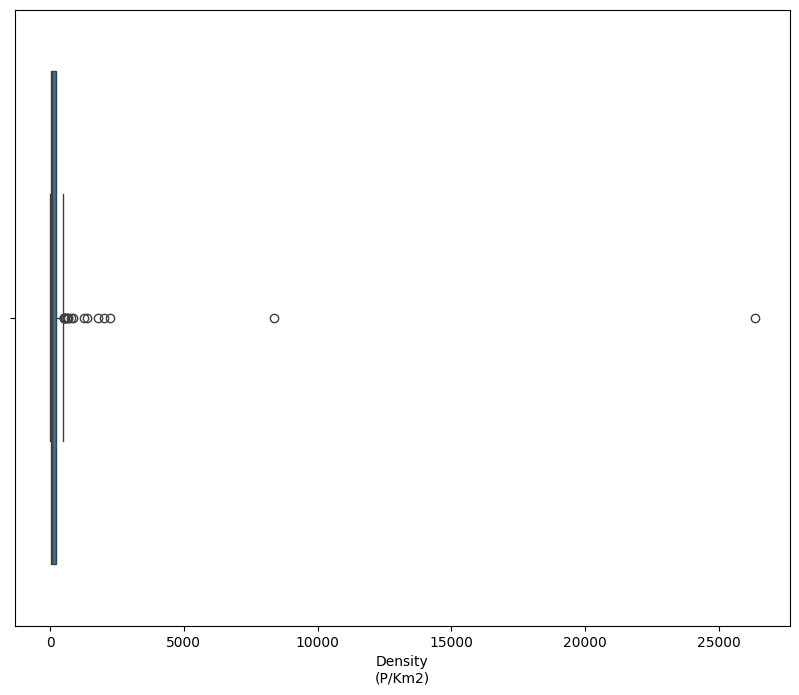

In [12]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='Density\n(P/Km2)')
plt.show()

In [13]:
df[df['Density\n(P/Km2)'] > 5000]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
113,Monaco,26337,MC,70.0,2.0,7184844.193,5.9,377.0,Monaco City,184396.986783,...,6.1,6.56,38964.0,60.0,40.822404,40.822404,10.00,38964.0,43.738418,7.424616
156,Singapore,8358,SG,0.9,716.0,81000.000,8.8,65.0,Abu Dhabi,37535.000000,...,36.7,2.29,5703569.0,70.5,13.100000,21.000000,4.11,5703569.0,1.352083,103.819836


In [14]:
df[df['Country'] == 'Monaco']

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
113,Monaco,26337,MC,70.0,2.0,7184844.193,5.9,377.0,Monaco City,184396.986783,...,6.1,6.56,38964.0,60.0,40.822404,40.822404,10.0,38964.0,43.738418,7.424616


In [15]:
df[df['Country'] == 'Singapore']

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
156,Singapore,8358,SG,0.9,716.0,81000.0,8.8,65.0,Abu Dhabi,37535.0,...,36.7,2.29,5703569.0,70.5,13.1,21.0,4.11,5703569.0,1.352083,103.819836


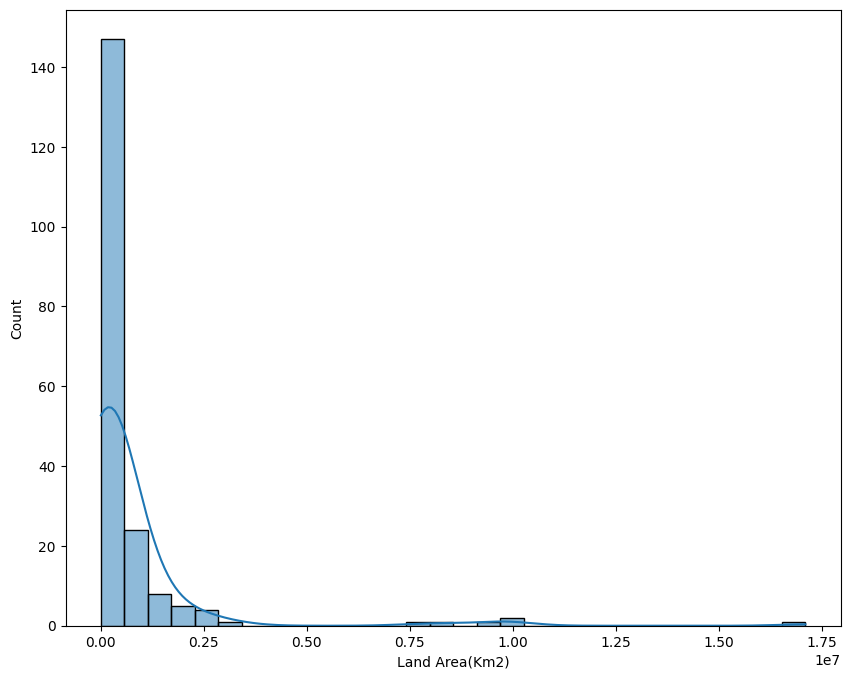

In [16]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Land Area(Km2)' , kde=True , bins=30 )
plt.show()

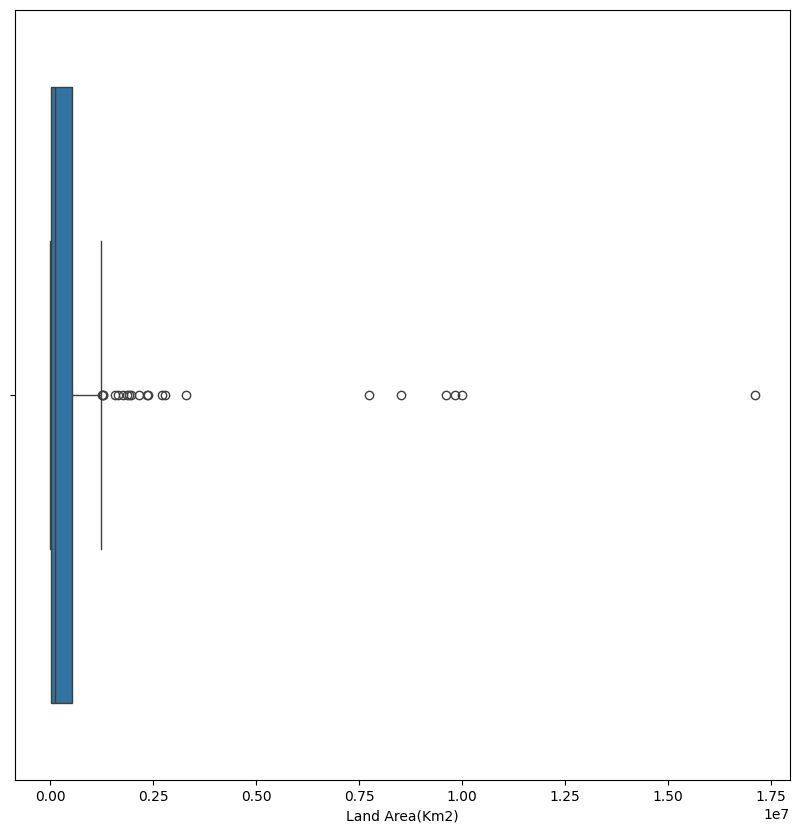

In [17]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df , x='Land Area(Km2)')
plt.show()

In [18]:
df['Land Area(Km2)'].agg(['min' , 'max' , 'mean'])

min     0.000000e+00
max     1.709824e+07
mean    6.863263e+05
Name: Land Area(Km2), dtype: float64

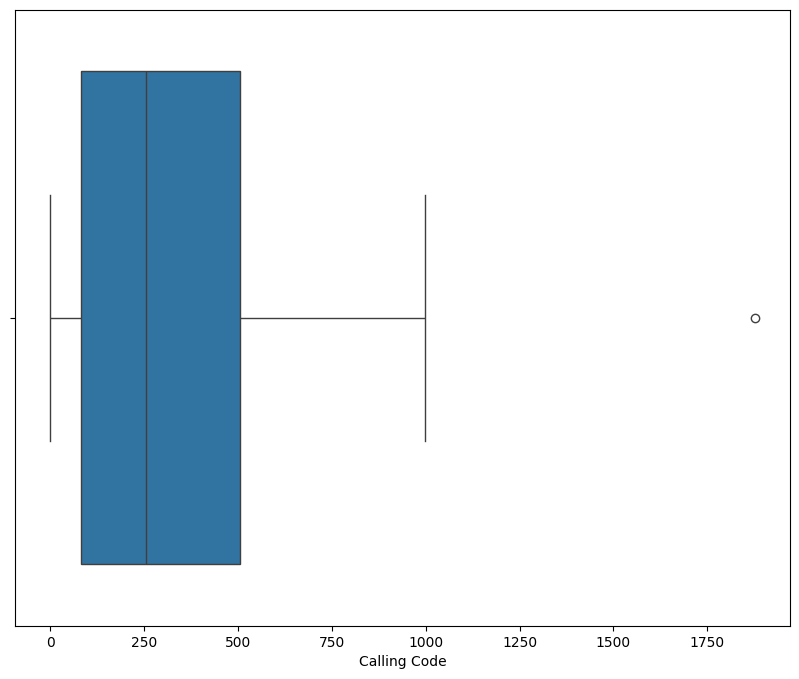

In [19]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='Calling Code')
plt.show()

In [20]:
df[df['Calling Code'] > 1500]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
84,Jamaica,273,JM,41.0,10991.0,4000.0,16.1,1876.0,Kingston Jamaica,8225.0,...,23.7,1.31,2948279.0,66.0,26.8,35.1,8.0,1650594.0,18.109581,-77.297508


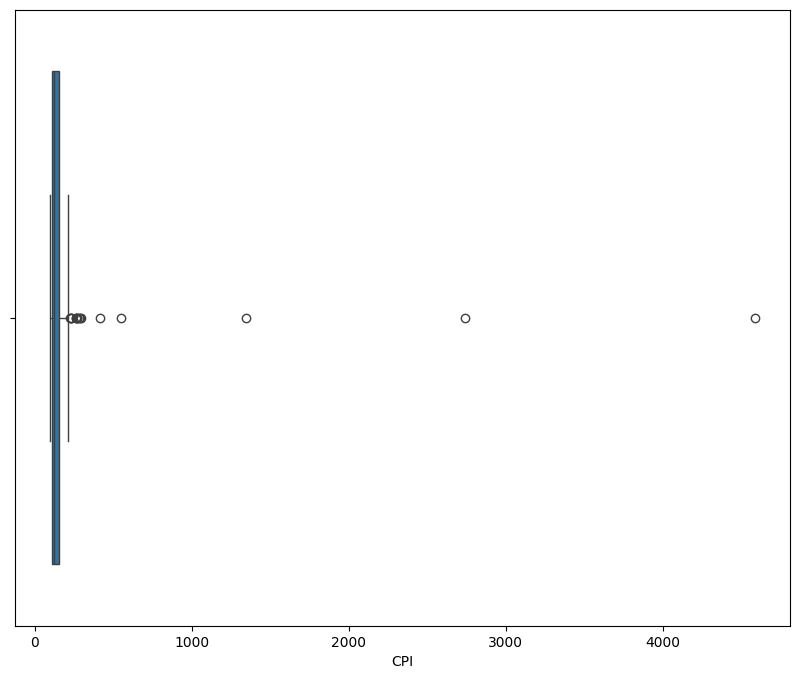

In [21]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='CPI')
plt.show()

In [22]:
df[df['CPI'] > 1000]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
163,South Sudan,18,SS,70.0,644329.0,185000.0,35.01,211.0,Juba,1727.0,...,61.3,0.0613,11062113.0,72.4,40.822404,31.4,12.24,2201250.0,6.876992,31.306979
166,Sudan,25,SD,28.7,1861484.0,124000.0,32.18,249.0,Khartoum,20000.0,...,63.2,0.2600,42813238.0,48.4,8.000000,45.4,16.53,14957233.0,12.862807,30.217636
190,Venezuela,32,VE,24.5,912050.0,343000.0,17.88,58.0,Caracas,164175.0,...,45.8,1.9200,28515829.0,59.7,40.822404,73.3,8.80,25162368.0,6.423750,-66.589730


In [23]:
df['Land Area(Km2)'].max()

np.float64(17098240.0)

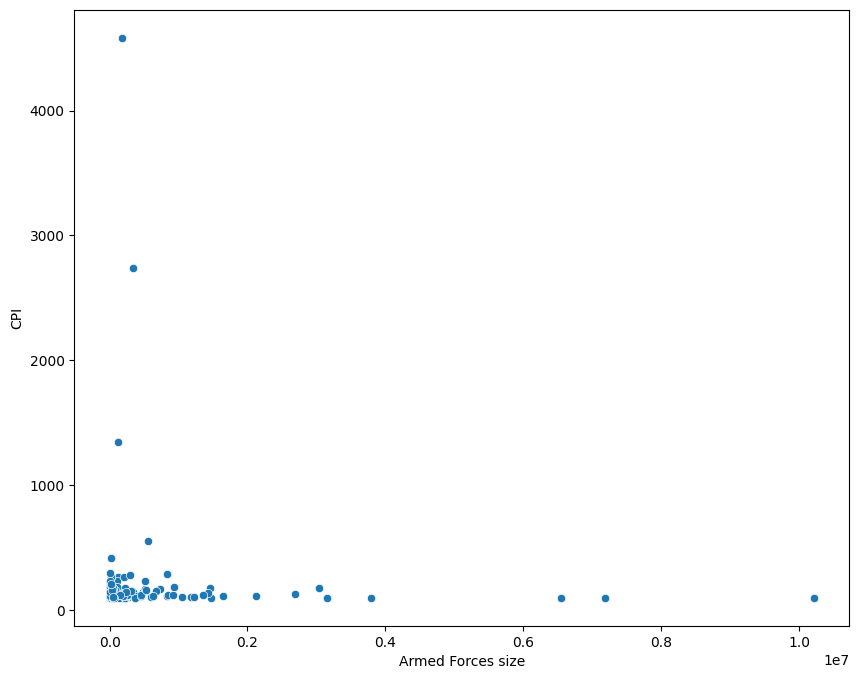

In [24]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df, x='Armed Forces size' , y='CPI')
plt.show()

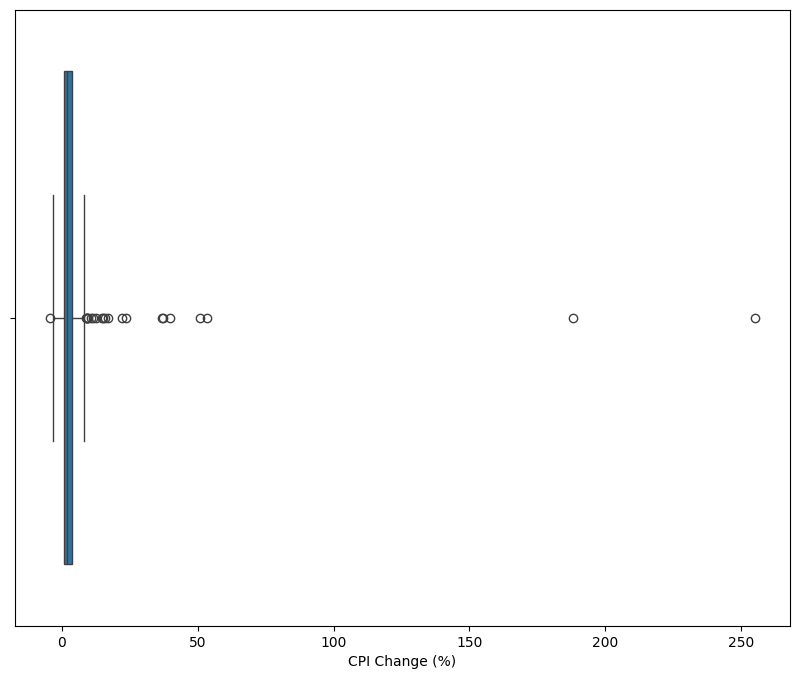

In [25]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='CPI Change (%)')
plt.show()

In [26]:
df[df['CPI Change (%)'] > 150 ]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
163,South Sudan,18,SS,70.0,644329.0,185000.0,35.01,211.0,Juba,1727.0,...,61.3,0.0613,11062113.0,72.4,40.822404,31.4,12.24,2201250.0,6.876992,31.306979
190,Venezuela,32,VE,24.5,912050.0,343000.0,17.88,58.0,Caracas,164175.0,...,45.8,1.9200,28515829.0,59.7,40.822404,73.3,8.80,25162368.0,6.423750,-66.589730


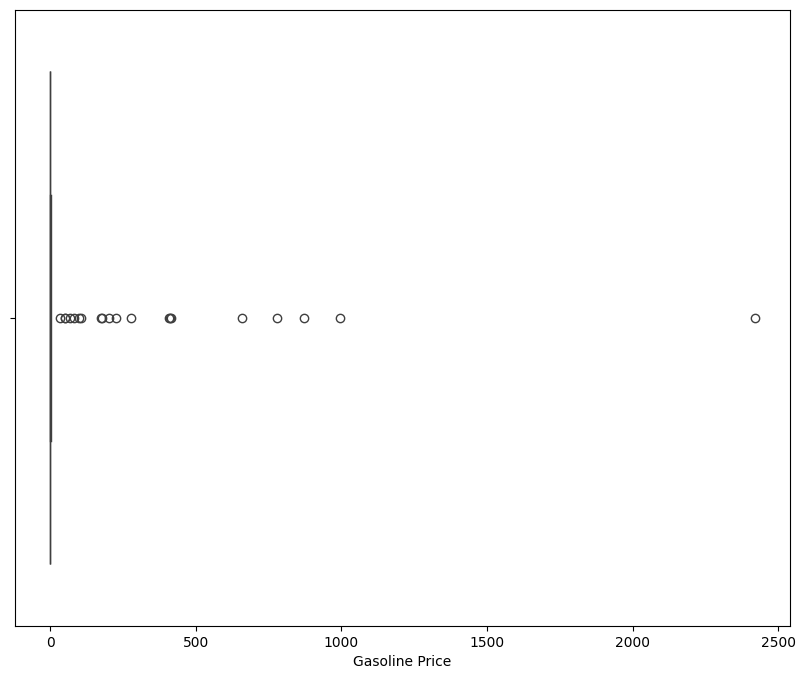

In [27]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='Gasoline Price')
plt.show()

In [28]:
df[df['Gasoline Price'] > 2000]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
149,San Marino,566,SM,16.7,61.0,1637931.034,6.8,378.0,City of San Marino,48373.627702,...,18.3,6.11,33860.0,60.0,18.1,36.2,10.0,32969.0,43.94236,12.457777


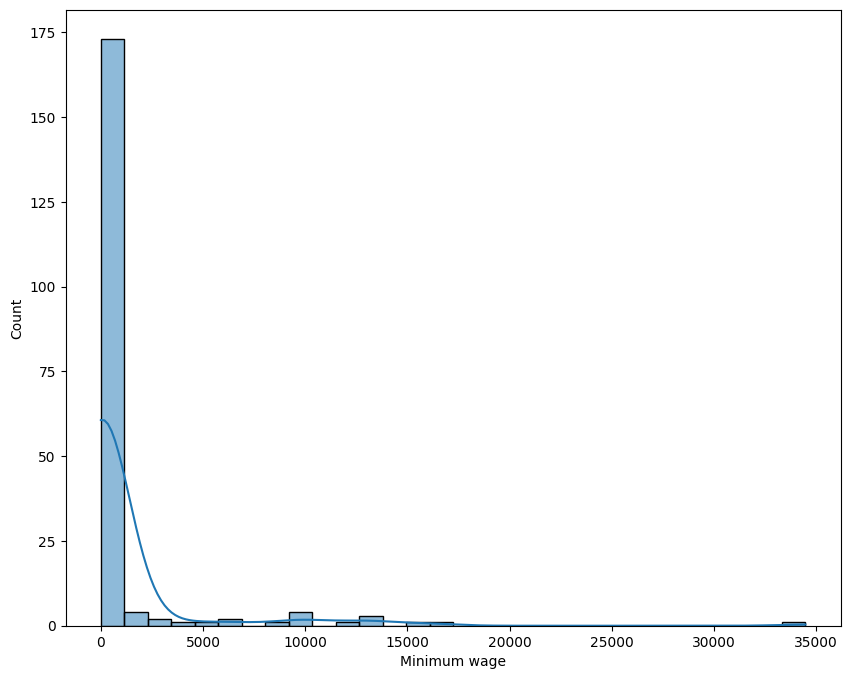

In [29]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Minimum wage' , kde=True , bins=30)
plt.show()

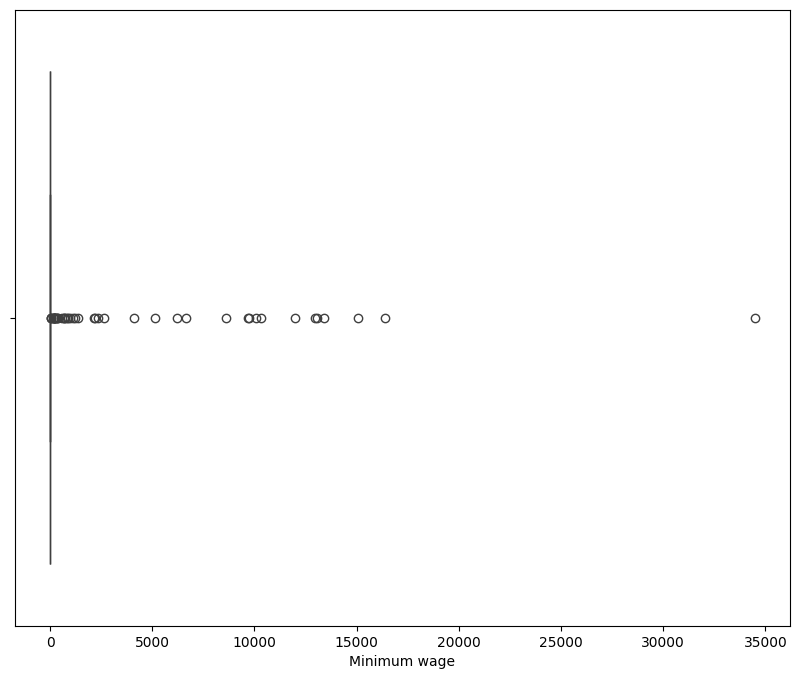

In [30]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='Minimum wage' )
plt.show()

In [31]:
df[df['Minimum wage'] > 30000]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
98,Liechtenstein,238,LI,32.2,160.0,6552858.739,9.9,423.0,Vaduz,51.0,...,8617.873615,8.617874,38019.0,60.0,40.822404,21.6,10.0,5464.0,47.141039,9.520935


In [32]:
df['Out of pocket health expenditure'].max()

np.float64(8617.873614508535)

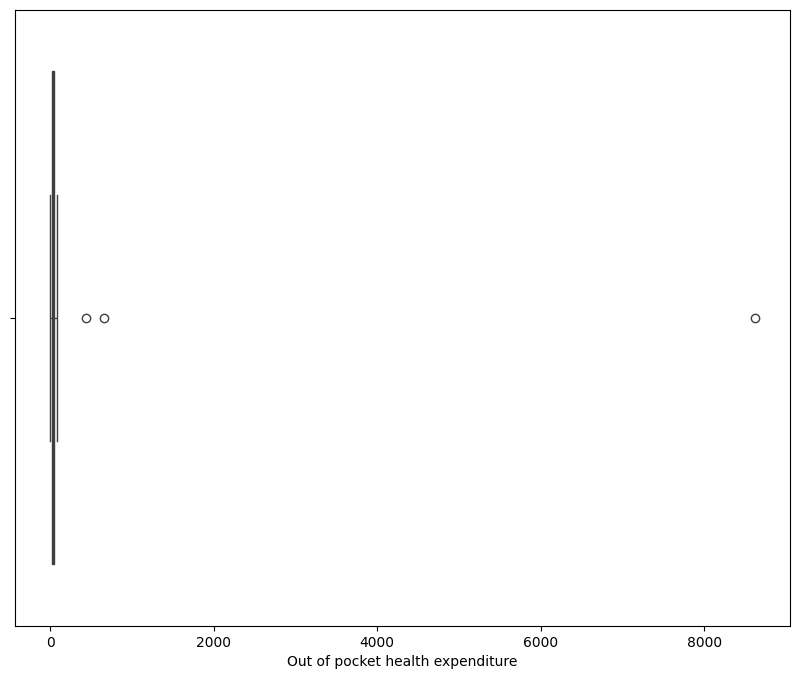

In [33]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='Out of pocket health expenditure' )
plt.show()

In [34]:
df[df['Out of pocket health expenditure'] > 6000]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
98,Liechtenstein,238,LI,32.2,160.0,6552858.739,9.9,423.0,Vaduz,51.0,...,8617.873615,8.617874,38019.0,60.0,40.822404,21.6,10.0,5464.0,47.141039,9.520935


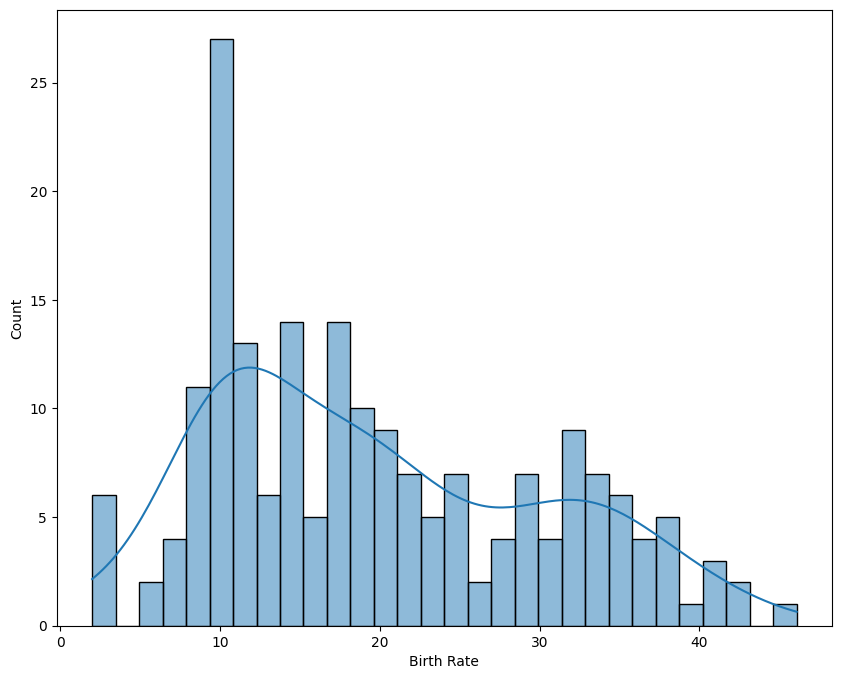

In [35]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Birth Rate' , kde=True , bins=30)
plt.show()

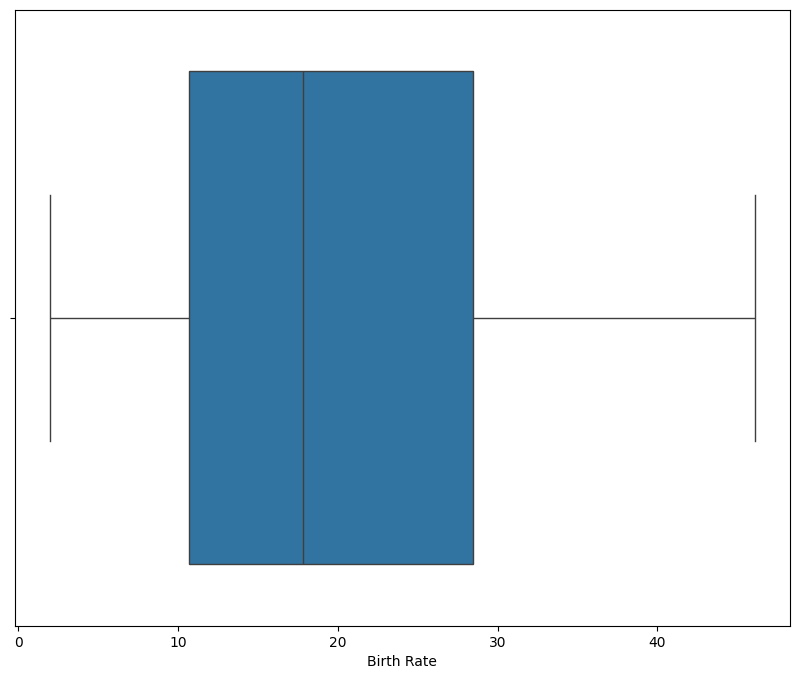

In [36]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='Birth Rate')
plt.show()

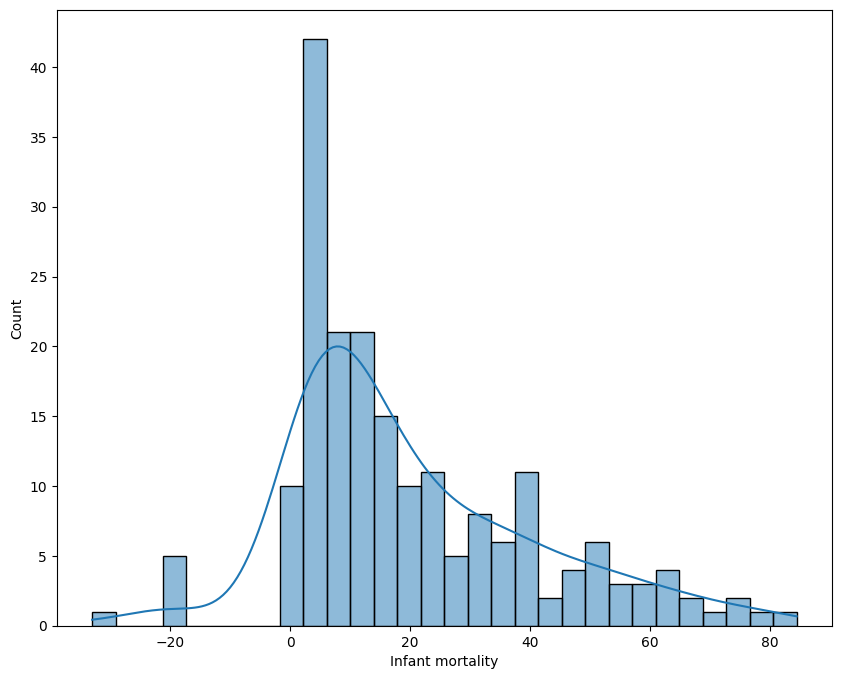

In [37]:
plt.figure(figsize=(10,8))
sns.histplot(data=df , x='Infant mortality' , kde=True , bins=30)
plt.show()

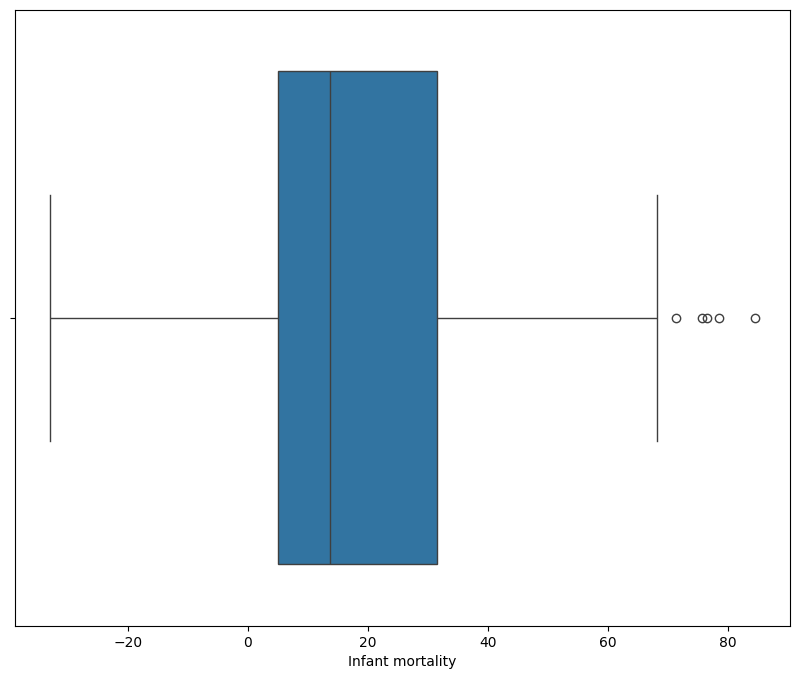

In [38]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='Infant mortality')
plt.show()

In [39]:
df[df['Infant mortality'] > 60 ]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
18,Benin,108,BJ,33.3,112622.0,12000.0,36.22,229.0,Porto-Novo,6476.0,...,40.500000,0.0800,11801151.0,70.9,10.800000,48.9,2.23,5648149.0,9.307690,2.315834
33,Central African Republic,8,CF,8.2,622984.0,8000.0,35.35,236.0,Bangui,297.0,...,39.600000,0.0600,4745185.0,72.0,8.600000,73.3,3.68,1982064.0,6.611111,20.939444
34,Chad,13,TD,39.7,1284000.0,35000.0,42.17,235.0,N'Djamena,1016.0,...,56.400000,0.0400,15946876.0,70.7,40.822404,63.5,1.89,3712273.0,15.454166,18.732207
45,Democratic Republic of the Congo,40,CD,11.6,2344858.0,134000.0,41.18,243.0,Kinshasa,2021.0,...,37.400000,0.0700,86790567.0,63.5,10.700000,50.7,4.24,39095679.0,-4.038333,21.758664
53,Equatorial Guinea,50,GQ,10.1,28051.0,1000.0,33.24,240.0,Malabo,5655.0,...,72.000000,0.4000,1355986.0,62.0,6.100000,79.4,6.43,984812.0,1.650801,10.267895
69,Guinea,53,GN,59.0,245857.0,13000.0,36.36,224.0,Conakry,2996.0,...,54.500000,0.0800,12771246.0,61.5,10.800000,69.3,4.30,4661505.0,9.945587,-9.696645
95,Lesotho,71,LS,77.6,30355.0,2000.0,26.81,266.0,Maseru,2512.0,...,16.900000,0.0700,2125268.0,67.9,31.600000,13.6,23.41,607508.0,-29.609988,28.233608
105,Mali,17,ML,33.8,1240192.0,18000.0,41.54,223.0,Bamako,3179.0,...,46.300000,0.1300,19658031.0,70.8,11.600000,54.5,7.22,8479688.0,17.570692,-3.996166
126,Nigeria,226,NG,77.7,923768.0,215000.0,37.91,234.0,Abuja,120369.0,...,72.200000,0.3800,200963599.0,52.9,1.500000,34.8,8.10,102806948.0,9.081999,8.675277
155,Sierra Leone,111,SL,54.7,71740.0,9000.0,33.41,232.0,Freetown,1093.0,...,38.200000,0.0300,7813215.0,57.9,8.600000,30.7,4.43,3319366.0,8.460555,-11.779889


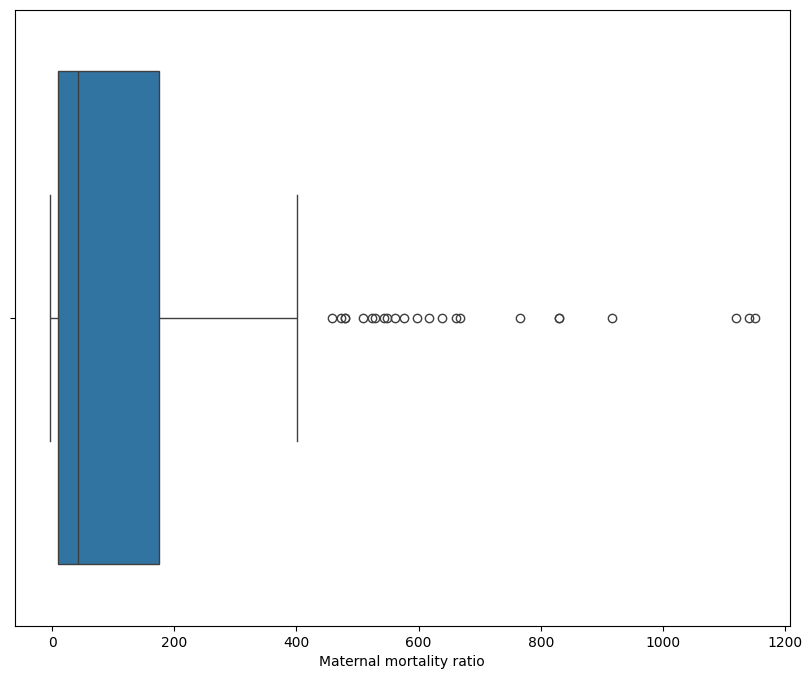

In [40]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df , x='Maternal mortality ratio')
plt.show()

In [41]:
df[df['Maternal mortality ratio'] > 1000]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
34,Chad,13,TD,39.7,1284000.0,35000.0,42.17,235.0,N'Djamena,1016.0,...,56.4,0.0400,15946876.0,70.7,40.822404,63.5,1.89,3712273.0,15.454166,18.732207
155,Sierra Leone,111,SL,54.7,71740.0,9000.0,33.41,232.0,Freetown,1093.0,...,38.2,0.0300,7813215.0,57.9,8.600000,30.7,4.43,3319366.0,8.460555,-11.779889
163,South Sudan,18,SS,70.0,644329.0,185000.0,35.01,211.0,Juba,1727.0,...,61.3,0.0613,11062113.0,72.4,40.822404,31.4,12.24,2201250.0,6.876992,31.306979


In [42]:
df['Life expectancy'].agg(['min' , 'max'])

min    52.8
max    85.4
Name: Life expectancy, dtype: float64

In [43]:
df[df['Life expectancy']  > 60 ]

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.1,652230.0,323000.000,32.49,93.0,Kabul,8672.0,...,78.4,0.28,38041754.0,48.9,9.300000,71.400000,11.12,9797273.0,33.939110,67.709953
1,Albania,105,AL,43.1,28748.0,9000.000,11.78,355.0,Tirana,4536.0,...,56.9,1.20,2854191.0,55.7,18.600000,36.600000,12.33,1747593.0,41.153332,20.168331
2,Algeria,18,DZ,17.4,2381741.0,317000.000,24.28,213.0,Algiers,150006.0,...,28.1,1.72,43053054.0,41.2,37.200000,66.100000,11.70,31510100.0,28.033886,1.659626
3,Andorra,164,AD,40.0,468.0,3154057.987,7.20,376.0,Andorra la Vella,469.0,...,36.4,3.33,77142.0,60.0,40.822404,40.822404,10.00,67873.0,42.506285,1.521801
4,Angola,26,AO,47.5,1246700.0,117000.000,40.73,244.0,Luanda,34693.0,...,33.4,0.21,31825295.0,77.5,9.200000,49.100000,6.89,21061025.0,-11.202692,17.873887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32,VE,24.5,912050.0,343000.000,17.88,58.0,Caracas,164175.0,...,45.8,1.92,28515829.0,59.7,40.822404,73.300000,8.80,25162368.0,6.423750,-66.589730
191,Vietnam,314,VN,39.3,331210.0,522000.000,16.75,84.0,Hanoi,192668.0,...,43.5,0.82,96462106.0,77.4,19.100000,37.600000,2.01,35332140.0,14.058324,108.277199
192,Yemen,56,YE,44.6,527968.0,40000.000,30.45,967.0,Sanaa,10609.0,...,81.0,0.31,29161922.0,38.0,40.822404,26.600000,12.91,10869523.0,15.552727,48.516388
193,Zambia,25,ZM,32.1,752618.0,16000.000,36.19,260.0,Lusaka,5141.0,...,27.5,1.19,17861030.0,74.6,16.200000,15.600000,11.43,7871713.0,-13.133897,27.849332


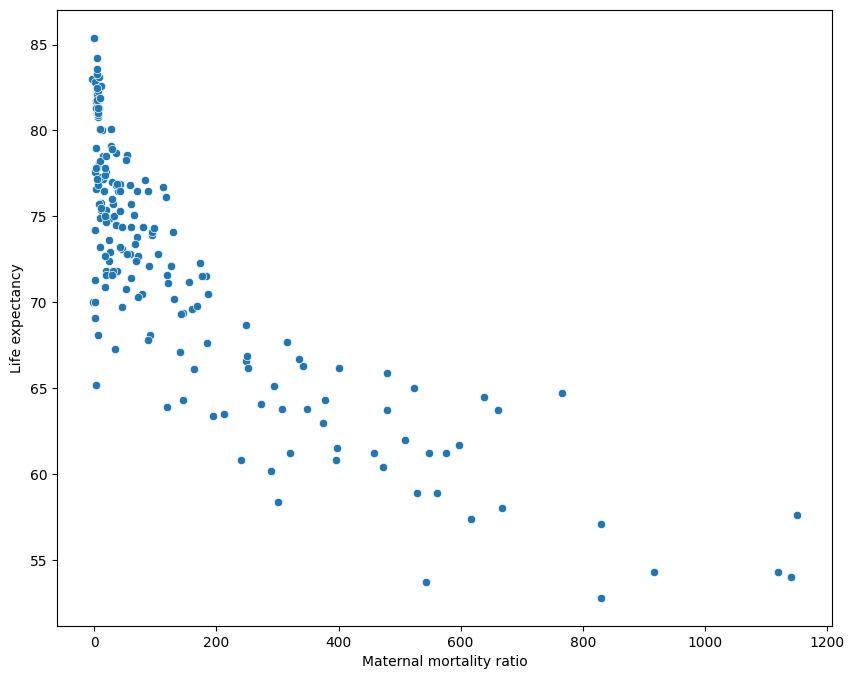

In [50]:
plt.figure(figsize=(10,8))
sns.scatterplot(data=df , x ='Maternal mortality ratio' , y='Life expectancy')
plt.show()

In [45]:
df.describe(include='O')

,Country,Abbreviation,Capital/Major City,Currency-Code,Largest city,Official language
count,195,195,195,195,195,195
unique,195,188,192,133,188,76
top,Afghanistan,AD,Abu Dhabi,EUR,S����,English
freq,1,8,4,38,8,36


In [46]:
df

,Country,Density\n(P/Km2),Abbreviation,Agricultural Land( %),Land Area(Km2),Armed Forces size,Birth Rate,Calling Code,Capital/Major City,Co2-Emissions,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,Afghanistan,60,AF,58.1,652230.0,323000.000,32.49,93.0,Kabul,8672.0,...,78.4,0.28,38041754.0,48.9,9.300000,71.400000,11.12,9797273.0,33.939110,67.709953
1,Albania,105,AL,43.1,28748.0,9000.000,11.78,355.0,Tirana,4536.0,...,56.9,1.20,2854191.0,55.7,18.600000,36.600000,12.33,1747593.0,41.153332,20.168331
2,Algeria,18,DZ,17.4,2381741.0,317000.000,24.28,213.0,Algiers,150006.0,...,28.1,1.72,43053054.0,41.2,37.200000,66.100000,11.70,31510100.0,28.033886,1.659626
3,Andorra,164,AD,40.0,468.0,3154057.987,7.20,376.0,Andorra la Vella,469.0,...,36.4,3.33,77142.0,60.0,40.822404,40.822404,10.00,67873.0,42.506285,1.521801
4,Angola,26,AO,47.5,1246700.0,117000.000,40.73,244.0,Luanda,34693.0,...,33.4,0.21,31825295.0,77.5,9.200000,49.100000,6.89,21061025.0,-11.202692,17.873887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,Venezuela,32,VE,24.5,912050.0,343000.000,17.88,58.0,Caracas,164175.0,...,45.8,1.92,28515829.0,59.7,40.822404,73.300000,8.80,25162368.0,6.423750,-66.589730
191,Vietnam,314,VN,39.3,331210.0,522000.000,16.75,84.0,Hanoi,192668.0,...,43.5,0.82,96462106.0,77.4,19.100000,37.600000,2.01,35332140.0,14.058324,108.277199
192,Yemen,56,YE,44.6,527968.0,40000.000,30.45,967.0,Sanaa,10609.0,...,81.0,0.31,29161922.0,38.0,40.822404,26.600000,12.91,10869523.0,15.552727,48.516388
193,Zambia,25,ZM,32.1,752618.0,16000.000,36.19,260.0,Lusaka,5141.0,...,27.5,1.19,17861030.0,74.6,16.200000,15.600000,11.43,7871713.0,-13.133897,27.849332


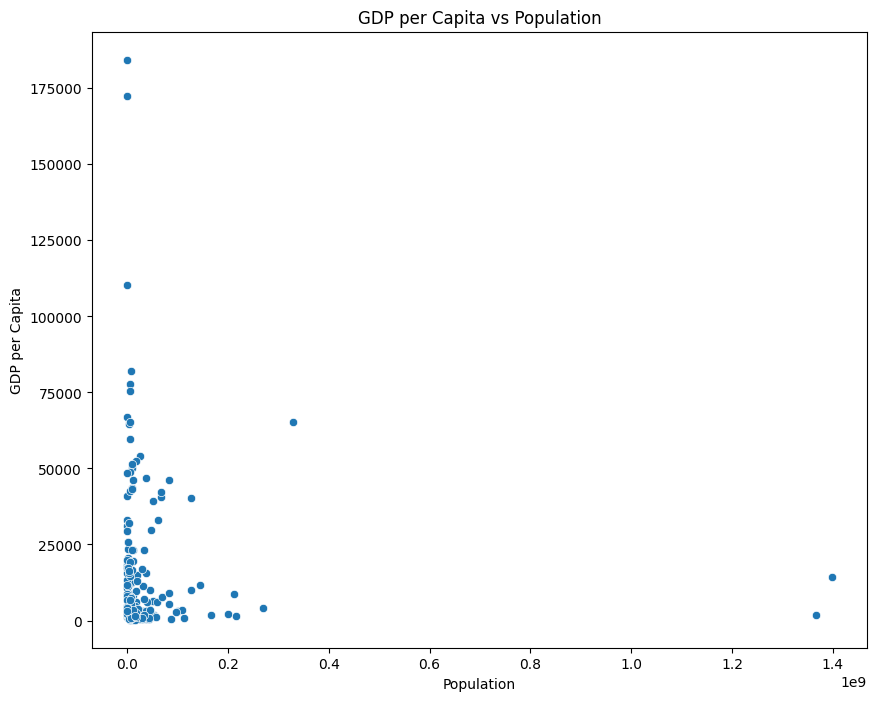

In [47]:
df['GDP per Capita'] = df['GDP'] / df['Population']
plt.figure(figsize=(10,8))
sns.scatterplot(x='Population', y='GDP per Capita', data=df)
plt.title("GDP per Capita vs Population")
plt.show()

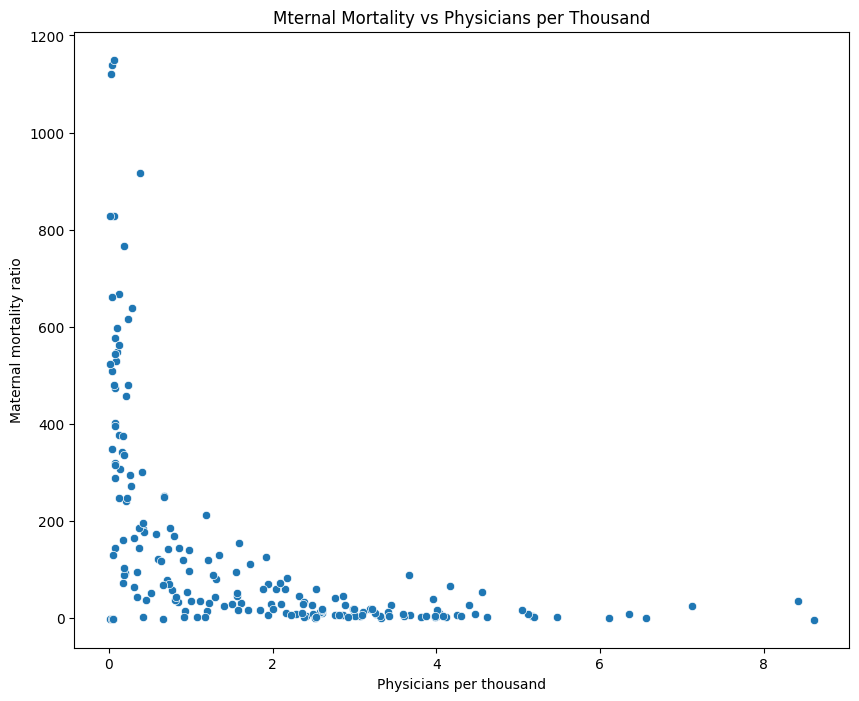

In [48]:
plt.figure(figsize=(10,8))
sns.scatterplot(x='Physicians per thousand', y='Maternal mortality ratio', data=df)
plt.title("Mternal Mortality vs Physicians per Thousand")
plt.show()